In [191]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import UnitaryGate
import numpy as np
import matplotlib.ticker as ticker
from scipy.linalg import svd
from qiskit.quantum_info import Statevector


In [192]:
simulator = AerSimulator()

Deviation from identity: 3.597533769998862e-16
Statevector([0.82287807+0.j, 0.54837655+0.j, 0.14884502+0.j,
             0.        +0.j],
            dims=(2, 2))
Statevector([ 0.82287807+0.j        ,  0.54640256-0.04648753j,
             -0.14246182-0.04312159j,  0.        +0.j        ],
            dims=(2, 2))
Statevector([ 0.95555793-0.0319111j , -0.19864183-0.05476604j,
             -0.20839841-0.00170999j,  0.        +0.j        ],
            dims=(2, 2))


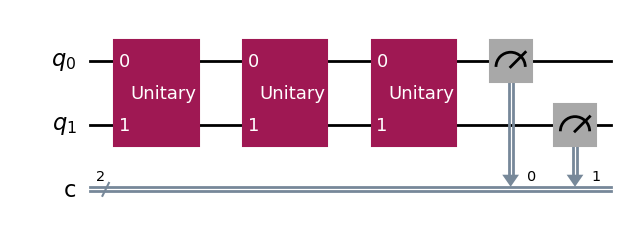

In [202]:
# Define mixing angles (in radians) and CP phase

theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(0)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # Transpose for Qiskit's column convention
    return U_4x4
# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability

def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))



# Create the quantum circuit
qc = QuantumCircuit(2, 2)

# STEP 1: Initialize mass=flavour state before mixing
initial_state = 'e'  # Choose 'e', 'mu', or 'tau'
if initial_state == 'e':
    pass
elif initial_state == 'mu':
    qc.x(1)  # |01> = ν_2=nu_mu
elif initial_state == 'tau':
    qc.x(0)  # |10> = ν_3=nu_tau

# STEP 2: Apply PMNS (write flavour state in mass basis)
qc.unitary(UnitaryGate(U_PMNS_dagger_4x4, label="U_PMNS"), [0, 1])
    #nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
    #qc.initialize(nu_mu_state, [0, 1])


state = Statevector.from_instruction(qc)
print(state)
# STEP 3: Apply time evolution in mass basis
sDm2 = 7.49e-5  # Delta_21 in eV^2
lDm2 = 2.513e-3  # Delta_31 in eV^2
hbar = 6.582e-16  # eV·s
c = 3e8  # m/s
L = 810e3  # NOvA baseline in meters
t = L / c  # time in seconds
E_values = np.arange(0.01, 5, 0.01)  # GeV
E = 1.81  # pick first energy value

# Convert mass-squared differences into angular frequencies
omega1 = sDm2 / (4 * E * 1e9 * hbar)  # rad/s
omega2 = lDm2 / (4 * E * 1e9 * hbar)  # rad/s

# Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
#evolution = np.eye(4, dtype=complex)
#evolution[1, 1] = np.exp(-1j * omega1 * t)  # |01⟩ = ν_2
#evolution[2, 2] = np.exp(-1j * omega2 * t)  # |10⟩ = ν_3
#U_evolution = UnitaryGate(evolution.T, label="e^(-iHt)")
#qc.unitary(U_evolution, [0, 1])
qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
    qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
    qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
state = Statevector.from_instruction(qc)
print(state)
# STEP 4: Apply U_PMNS† to rotate back to flavour basis
qc.unitary(UnitaryGate(U_PMNS_dagger_4x4.T, label="U_PMNS†"), [0, 1])
state = Statevector.from_instruction(qc)
print(state)
# STEP 5: Measure
qc.measure([0, 1], [0, 1])

# Simulate (optional)
# backend = Aer.get_backend('qasm_simulator')
# job = execute(qc, backend, shots=1024)
# result = job.result()
# counts = result.get_counts()
# print("Measurement results:", counts)

# Draw circuit
qc.draw('mpl')


Row representation: [-0.40358928-0.08494618j  0.60561446-0.05660923j  0.6781787 +0.j
  0.        +0.j        ]
Column representation: [ 0.54837655+0.j          0.60561446-0.05660923j -0.5707022 -0.06007226j
  0.        +0.j        ]
[1. 1. 1. 1.]
[1. 1. 1. 1.]
Deviation from identity: 7.98614455229497e-16


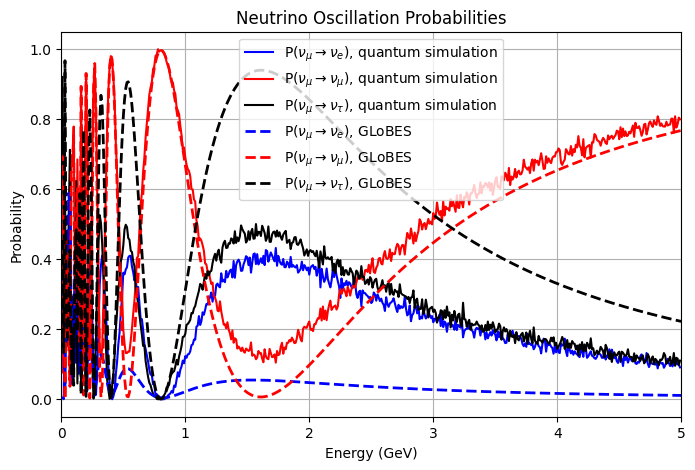

In [208]:
theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(-90)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # No transposition!
    print("Row representation:", U_4x4[1, :])
    print("Column representation:", U_4x4[:, 1])

    return U_4x4

# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
print(np.linalg.norm(U_PMNS_4x4, axis=0))
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability
def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
print(np.linalg.norm(U_PMNS_4x4, axis=0))
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))

# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
for E in E_values:
    # Create the quantum circuit
    qc = QuantumCircuit(2, 2)

     ###STEP 1: Initialize mass state before mixing
    initial_state = 'mu'  # Choose 'e', 'mu', or 'tau'
    if initial_state == 'e':
        pass
    elif initial_state == 'mu':
        qc.x(1)  # |01> = ν_2
    elif initial_state == 'tau':
        qc.x(0)  # |10> = ν_3

    # STEP 2: Apply PMNS (write flavour state in mass basis)
    qc.unitary(UnitaryGate(U_PMNS_dagger_4x4, label="U_PMNS"), [0, 1])
    #nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
    #qc.initialize(nu_mu_state, [0, 1])


    # STEP 3: Apply time evolution in mass basis
    sDm2 = 7.49e-5  # Delta_21 in eV^2
    lDm2 = 2.513e-3  # Delta_31 in eV^2
    hbar = 6.582e-16  # eV·s
    c = 3e8  # m/s
    L = 810e3  # NOvA baseline in meters
    t = L / c  # time in seconds
    
    # Convert mass-squared differences into angular frequencies
    omega0 = 0
    omega1 = sDm2 / (4 * E * 1e9 * hbar)  # rad/s
    omega2 = lDm2 / (4 * E * 1e9 * hbar)  # rad/s
    qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
    qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
    qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
    # Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
    #evolution = np.eye(4, dtype=complex)
    #evolution[:3, :3] = np.diag(np.exp(-1j * np.array([omega0, omega1, omega2]) * t))
    #U_evolution = UnitaryGate(evolution, label="e^(-iHt)")
    #qc.unitary(U_evolution, [0, 1])

    # STEP 4: Apply U_PMNS† to rotate back to flavour basis
    qc.unitary(UnitaryGate(U_PMNS_4x4, label="U_PMNS†"), [0, 1])

    # STEP 5: Measure
    qc.measure([0, 1], [0, 1])
    
    ##### Run the circuit#######
    pqc = transpile(qc, simulator)
    job = simulator.run(qc, shots=1024)
    job_result = job.result()
    counts = job_result.get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])  # Sum over 3 relevant states
    #print(total_counts)
    ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E :.2f} GeV -> Probability: {probability}")
    probability_nue = counts.get('00', 0) / (total_counts)  # nu_mu-->nu_e survival probability
    probability_numu = counts.get('10', 0) / total_counts  # nu_mu-->nu_mu oscillation probability
    probability_nutau = counts.get('01', 0) / total_counts # nu_mu-->nu_tau oscillation probability
    #print(probability_nue+probability_numu+probability_nutau)
    # Store values
    E_list.append(E)
    P_nue_list.append(probability_nue)
    P_numu_list.append(probability_numu)
    P_nutau_list.append(probability_nutau)
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nue_numu_nova.dat", unpack=True)

# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
plt.plot(E_list, P_nue_list, label=r'P($\nu_\mu \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_\mu \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\nu_\mu \to \nu_\tau$), quantum simulation', linestyle='-', color='black')
# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_\mu \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_\mu \to \nu_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\nu_\mu \to \nu_\tau$), GLoBES')
# Fix the x-axis range
plt.xlim(0, 5)  # Set range explicitly

# Labels and title
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities")
plt.legend()
plt.grid()
plt.show()


Row representation: [-0.40358928-0.08494618j  0.60561446-0.05660923j  0.6781787 +0.j
  0.        +0.j        ]
Column representation: [ 0.54837655+0.j          0.60561446-0.05660923j -0.5707022 -0.06007226j
  0.        +0.j        ]
[1. 1. 1. 1.]
[1. 1. 1. 1.]
Deviation from identity: 7.98614455229497e-16


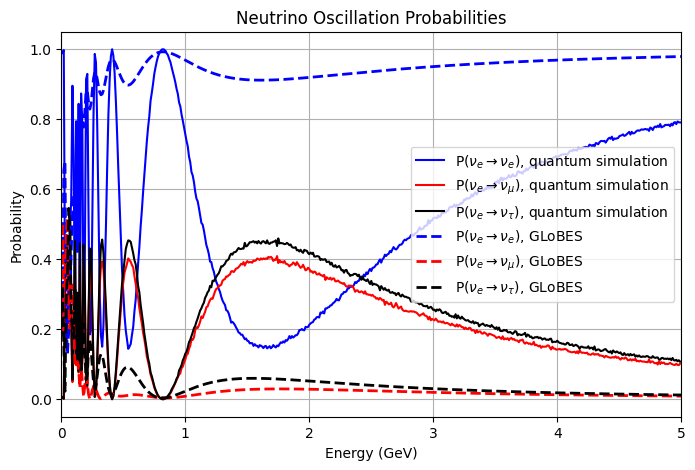

In [206]:
theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])  # nu-fit values for NH
delta_CP = np.radians(-90)

# Define the PMNS matrix
# Define the PMNS matrix and embed it in a 4x4 unitary
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c12, s12 = np.cos(theta_12), np.sin(theta_12)
    c13, s13 = np.cos(theta_13), np.sin(theta_13)
    c23, s23 = np.cos(theta_23), np.sin(theta_23)
    e_idelta = np.exp(-1j * delta_CP)

    # 3x3 PMNS matrix
    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_idelta, c12 * c23 - s12 * s23 * s13 * e_idelta, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_idelta, -c12 * s23 - s12 * c23 * s13 * e_idelta, c23 * c13]
    ], dtype=complex)

    # Embed in 4x4 matrix
    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[np.ix_([0,1,2],[0,1,2])] = U  # No transposition!
    print("Row representation:", U_4x4[1, :])
    print("Column representation:", U_4x4[:, 1])

    return U_4x4

# Compute U_PMNS and its Hermitian conjugate
U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
print(np.linalg.norm(U_PMNS_4x4, axis=0))
# Project U_PMNS_4x4 to the nearest unitary to ensure numerical stability
def project_to_unitary(U):
    U_svd, _, Vh = svd(U)
    return U_svd @ Vh

U_PMNS_4x4 = project_to_unitary(U_PMNS_4x4)
print(np.linalg.norm(U_PMNS_4x4, axis=0))
U_PMNS_dagger_4x4 = U_PMNS_4x4.conj().T
unitarity_check = U_PMNS_dagger_4x4 @ U_PMNS_4x4
print("Deviation from identity:", np.linalg.norm(unitarity_check - np.eye(4)))

# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []
P_nutau_list = []
for E in E_values:
    # Create the quantum circuit
    qc = QuantumCircuit(2, 2)

     ###STEP 1: Initialize mass state before mixing
    initial_state = 'e'  # Choose 'e', 'mu', or 'tau'
    if initial_state == 'e':
        pass
    elif initial_state == 'mu':
        qc.x(1)  # |01> = ν_2
    elif initial_state == 'tau':
        qc.x(0)  # |10> = ν_3

    # STEP 2: Apply PMNS (write flavour state in mass basis)
    qc.unitary(UnitaryGate(U_PMNS_dagger_4x4, label="U_PMNS"), [0, 1])
    #nu_mu_state = U_PMNS_4x4[:, 1] / np.linalg.norm(U_PMNS_4x4[:, 1])  # Normalize state
    #qc.initialize(nu_mu_state, [0, 1])


    # STEP 3: Apply time evolution in mass basis
    sDm2 = 7.49e-5  # Delta_21 in eV^2
    lDm2 = 2.513e-3  # Delta_31 in eV^2
    hbar = 6.582e-16  # eV·s
    c = 3e8  # m/s
    L = 810e3  # NOvA baseline in meters
    t = L / c  # time in seconds
    
    # Convert mass-squared differences into angular frequencies
    omega0 = 0
    omega1 = sDm2 / (4 * E * 1e9 * hbar)  # rad/s
    omega2 = lDm2 / (4 * E * 1e9 * hbar)  # rad/s
    qc.rz(2* omega0 * t, 0)  # Phase rotation for |ν_1>
    qc.rz(2* omega1 * t, 1)  # Phase rotation for |ν_2>
    qc.rz(2* omega2 * t, 0)  # Phase rotation for |ν_3>
    # Build time evolution operator: diag(1, e^{-iΔ21 t}, e^{-iΔ31 t}, 1)
    #evolution = np.eye(4, dtype=complex)
    #evolution[:3, :3] = np.diag(np.exp(-1j * np.array([omega0, omega1, omega2]) * t))
    #U_evolution = UnitaryGate(evolution.T, label="e^(-iHt)")
    #qc.unitary(U_evolution, [0, 1])

    # STEP 4: Apply U_PMNS† to rotate back to flavour basis
    qc.unitary(UnitaryGate(U_PMNS_4x4, label="U_PMNS†"), [0, 1])

    # STEP 5: Measure
    qc.measure([0, 1], [0, 1])
    
    ##### Run the circuit#######
    pqc = transpile(qc, simulator)
    job = simulator.run(qc, shots=16384)
    job_result = job.result()
    counts = job_result.get_counts()
    total_counts = sum([counts.get(state, 0) for state in ['00', '01', '10']])  # Sum over 3 relevant states
    raw_probabilities = {state: count / 1024 for state, count in counts.items()}
    #print(f"Raw counts: {counts}, Normalized: {raw_probabilities}")

    #print(total_counts)
    ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E :.2f} GeV -> Probability: {probability}")
    probability_nue = counts.get('00', 0) / (total_counts)  # nu_e-->nu_e survival probability
    probability_numu = counts.get('10', 0) / total_counts  # nu_e-->nu_mu oscillation probability
    probability_nutau = counts.get('01', 0) / total_counts # nu_e-->nu_tau oscillation probability
    #print(probability_nue+probability_numu+probability_nutau)
    # Store values
    E_list.append(E)
    P_nue_list.append(probability_nue)
    P_numu_list.append(probability_numu)
    P_nutau_list.append(probability_nutau)
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu, glb_P_nutau = np.loadtxt("prob_nue_numu_nova_initial_nue.dat", unpack=True)

# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
plt.plot(E_list, P_nue_list, label=r'P($\nu_e \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_e \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
plt.plot(E_list, P_nutau_list, label=r'P($\nu_e \to \nu_\tau$), quantum simulation', linestyle='-', color='black')
# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_e \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_e \to \nu_\mu$), GLoBES')
plt.plot(glb_E, glb_P_nutau, linestyle='--', color='black', linewidth=2, label=r'P($\nu_e \to \nu_\tau$), GLoBES')
# Fix the x-axis range
plt.xlim(0, 5)  # Set range explicitly

# Labels and title
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities")
plt.legend()
plt.grid()
plt.show()
